# Data-Driven Risk Analysis and Claim Prediction in Insurance using Open-Source Technologies

**Author:** Kaustav Purkayastha — LPU MCA Final Year  
**Role:** Data Engineer — Deloitte  

## Project Description
This project applies Data Science techniques in the insurance domain to analyze customer and policy data, identify risk patterns, and predict the likelihood of claims. A publicly available insurance dataset (e.g., from Kaggle) will be used. The analysis demonstrates the use of Python, SQL (SQLite), and machine learning modeling, with visualizations and actionable business insights for risk and claim management.

In [2]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import requests

sns.set(style="whitegrid", palette="muted")

# === Create project folders ===
os.makedirs("data", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

print("Imports done and folders created successfully!")

Matplotlib is building the font cache; this may take a moment.


Imports done and folders created successfully!


In [3]:
# Download insurance CSV to data folder
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data_path = "data/insurance.csv"

if not os.path.exists(data_path):
    r = requests.get(DATA_URL)
    with open(data_path, 'wb') as f:
        f.write(r.content)
    print(f"Dataset downloaded to {data_path}")
else:
    print(f"Dataset already exists at {data_path}")

# Load dataset
df = pd.read_csv(data_path)
print("Dataset loaded successfully!")
df.head()

Dataset downloaded to data/insurance.csv
Dataset loaded successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Data Overview
print("Shape of dataset:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all').T)


Shape of dataset: (1338, 7)

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
# Clean Categorical Fields
for col in ['sex','smoker','region']:
    df[col] = df[col].str.strip().str.lower()

# Save to SQLite Database
conn = sqlite3.connect("outputs/insurance.db") # database file
df.to_sql("insurance", conn, if_exists="replace", index=False)
conn.close()

print("Categorical fields cleaned and dataset saved to SQLite database at outputs/insurance.db")


Categorical fields cleaned and dataset saved to SQLite database at outputs/insurance.db


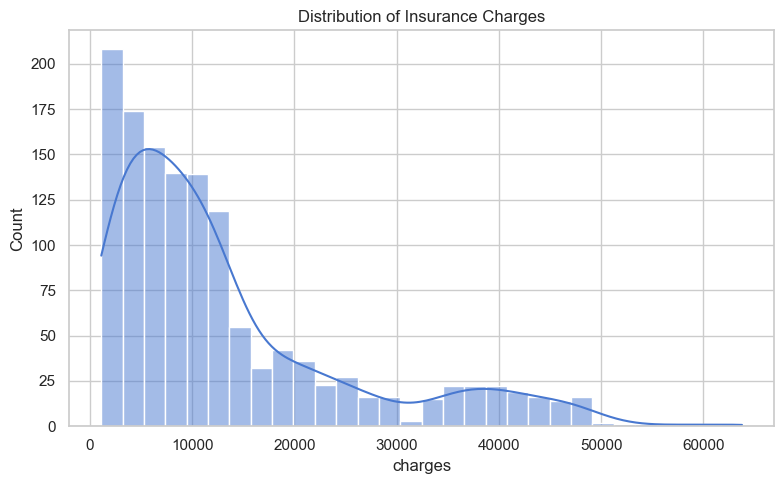

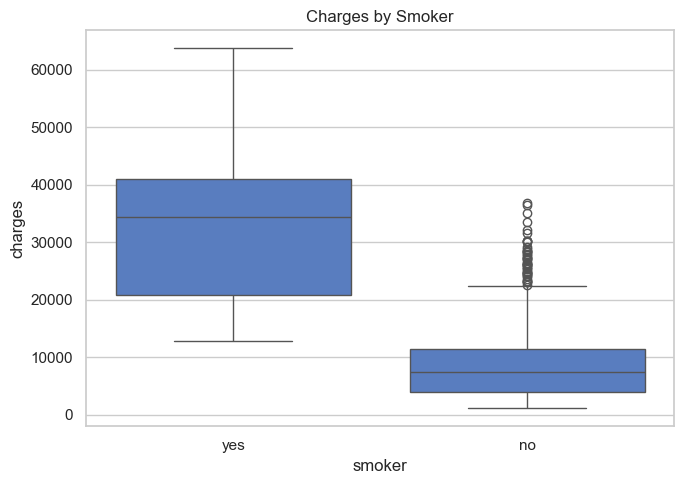

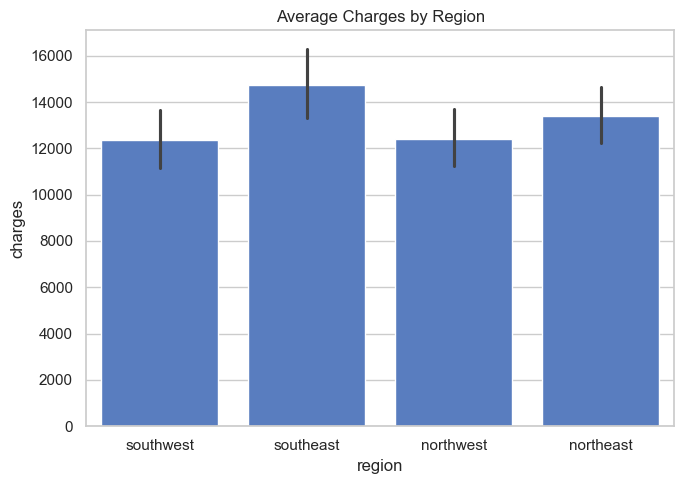

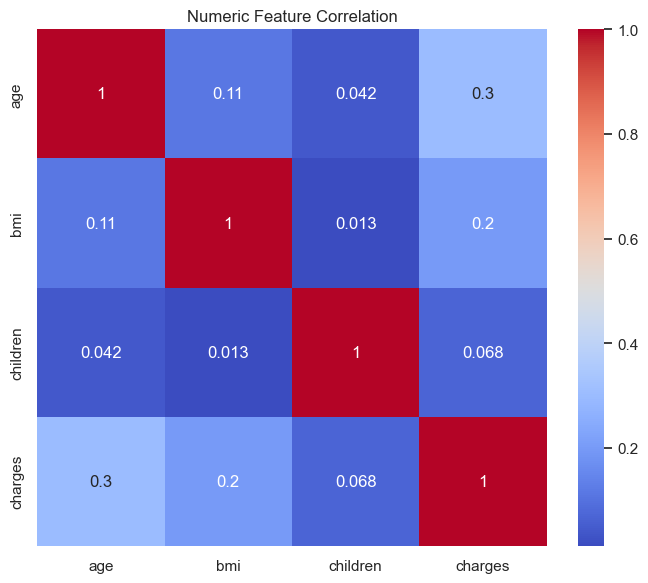

In [6]:
# Exploratory Data Analysis & Plots

# 1. Distribution of charges
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.tight_layout()
plt.savefig("outputs/figures/charges_distribution.png", dpi=150)
plt.show()

# 2. Charges by smoker
plt.figure(figsize=(7,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker')
plt.tight_layout()
plt.savefig("outputs/figures/charges_by_smoker.png", dpi=150)
plt.show()

# 3. Average charges by region
plt.figure(figsize=(7,5))
sns.barplot(x='region', y='charges', data=df, estimator=np.mean)
plt.title('Average Charges by Region')
plt.tight_layout()
plt.savefig("outputs/figures/avg_charges_by_region.png", dpi=150)
plt.show()

# 4. Correlation heatmap (numeric features)
plt.figure(figsize=(7,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Numeric Feature Correlation')
plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=150)
plt.show()


In [7]:
# Feature Engineering

# Create age bands
df['age_band'] = pd.cut(df['age'], bins=[17,25,35,45,55,65],
                        labels=['18-25','26-35','36-45','46-55','56-65'])
# Create smoker flag
df['smoker_flag'] = df['smoker'].map({'yes':1,'no':0})

# Display first few rows
df.head()


,age,sex,bmi,children,smoker,region,charges,age_band,smoker_flag
0,19,female,27.900,0,yes,southwest,16884.92400,18-25,1
1,18,male,33.770,1,no,southeast,1725.55230,18-25,0
2,28,male,33.000,3,no,southeast,4449.46200,26-35,0
3,33,male,22.705,0,no,northwest,21984.47061,26-35,0
4,32,male,28.880,0,no,northwest,3866.85520,26-35,0


In [11]:
# === Model Training & Evaluation ===

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import numpy as np

TARGET = 'charges'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = ['sex','smoker','region']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
('num', 'passthrough', num_cols),
('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Linear Regression pipeline
model = Pipeline([
('preproc', preprocessor),
('reg', LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Ensure numeric arrays to avoid TypeError
y_test_array = np.ravel(np.array(y_test))
y_pred_array = np.ravel(np.array(y_pred))

# Compute MSE first
mse = mean_squared_error(y_test_array, y_pred_array)
# Take square root for RMSE
rmse = sqrt(mse)

r2 = r2_score(y_test_array, y_pred_array)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")


RMSE: 5796.28
R² Score: 0.784


In [12]:
# === Save the trained model ===
import joblib

model_path = "outputs/models/insurance_model.pkl"
joblib.dump(model, model_path)

print(f"Trained model saved at {model_path}")


Trained model saved at outputs/models/insurance_model.pkl


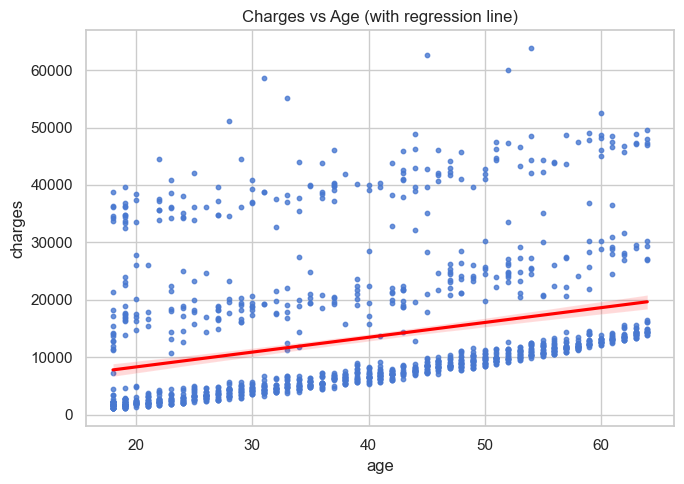

In [13]:
# Extra Visualization

plt.figure(figsize=(7,5))
sns.regplot(x='age', y='charges', data=df, scatter_kws={'s':10}, line_kws={'color':'red'})
plt.title('Charges vs Age (with regression line)')
plt.tight_layout()
plt.savefig("outputs/figures/charges_vs_age_regplot.png", dpi=150)
plt.show()


## Business Insights (Executive Summary)

- **Smoker effect:** Smokers incur significantly higher premiums; smoking status is the strongest predictor.
- **Age & BMI:** Charges grow with age and BMI; customers aged 45+ show steep increase in predicted cost.
- **Region:** Minimal effect on premium; standardized pricing across regions.
- **Actionable recommendation:** Flag the top 10% predicted-cost cohort for targeted underwriting review and tailored pricing.


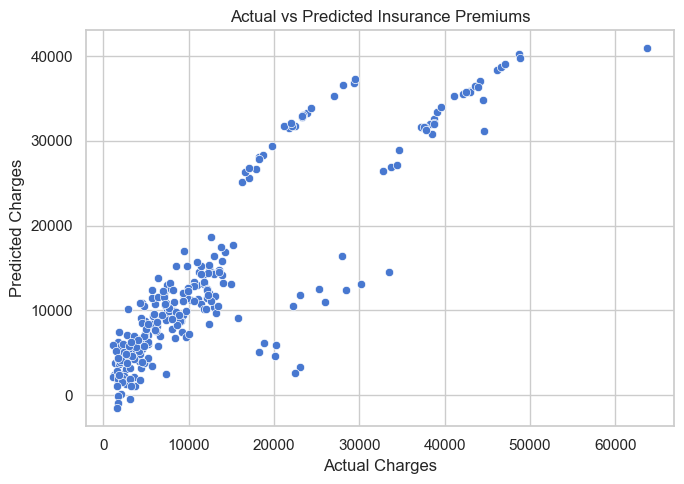

In [15]:
# Actual vs Predicted Plot

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Premiums")
plt.tight_layout()
plt.savefig("outputs/figures/actual_vs_predicted.png", dpi=150)
plt.show()
